In [1]:
import pandas as pd
from collections import Counter

res = pd.read_csv("../results/baseline_predictions.csv").fillna("")
clin = res[res["domain"] == "clinical"]

seen, missed = Counter(), Counter()
for ref, pred in zip(clin["ref_norm"], clin["pred_norm"]):
    pred_words = set(pred.split())
    for w in set(ref.split()):
        if len(w) >= 6:         
            seen[w] += 1
            if w not in pred_words:
                missed[w] += 1

table = pd.DataFrame(
    [(w, seen[w], missed[w], round(missed[w] / seen[w], 2)) for w in seen if seen[w] >= 3],
    columns=["word", "appearances", "missed", "miss_rate"],
).sort_values(["miss_rate", "appearances"], ascending=False)

print(table.head(25).to_string(index=False))

       word  appearances  missed  miss_rate
     infant            6       6       1.00
     murmur            3       3       1.00
     hernia            3       3       1.00
     weaned            3       3       1.00
     artery            4       3       0.75
   pressure            4       3       0.75
   catheter            4       3       0.75
     breast            4       3       0.75
     reason            6       4       0.67
     muscle            6       4       0.67
     taking            3       2       0.67
     portal            3       2       0.67
     lumbar            3       2       0.67
     course            3       2       0.67
     needed            3       2       0.67
 infarction            3       2       0.67
     sepsis            3       2       0.67
 parenteral            3       2       0.67
     states            3       2       0.67
     amount            3       2       0.67
unspecified            8       4       0.50
  displaced            6       3

In [2]:
for phrase in ["full stop", "comma", "period", "new line"]:
    n_pred = res["pred_norm"].str.contains(rf"\b{phrase}\b").sum()
    n_ref = res["ref_norm"].str.contains(rf"\b{phrase}\b").sum()
    print(f"'{phrase}': in predictions {n_pred}, in references {n_ref}")

joined = res["reference"].str.contains(r"[a-z][A-Z]", regex=True)
print("\nReferences with joined words:", joined.sum(), "of", len(res))

'full stop': in predictions 308, in references 0
'comma': in predictions 102, in references 0
'period': in predictions 7, in references 7
'new line': in predictions 1, in references 1

References with joined words: 40 of 1184


In [3]:
import re, jiwer

def drop_spoken_punct(t):
    return " ".join(re.sub(r"\b(full stop|comma)\b", " ", t).split())

res["pred_clean"] = res["pred_norm"].map(drop_spoken_punct)
no_joined = ~res["reference"].str.contains(r"[a-z][A-Z]", regex=True)

def wer(df, col):
    return jiwer.wer(list(df["ref_norm"]), list(df[col]))

print(f"Raw baseline WER:                     {wer(res, 'pred_norm'):.1%}")
print(f"After removing spoken 'full stop'/'comma': {wer(res, 'pred_clean'):.1%}")
print(f"...and excluding the 40 joined-word clips: {wer(res[no_joined], 'pred_clean'):.1%}\n")

for (acc, dom), g in res.groupby(["accent", "domain"]):
    print(f"{acc:7s} {dom:9s} raw {wer(g, 'pred_norm'):.1%}  ->  adjusted {wer(g, 'pred_clean'):.1%}")

Raw baseline WER:                     37.7%
After removing spoken 'full stop'/'comma': 33.1%
...and excluding the 40 joined-word clips: 32.1%

hausa   clinical  raw 43.9%  ->  adjusted 41.6%
hausa   general   raw 26.3%  ->  adjusted 19.6%
igbo    clinical  raw 38.9%  ->  adjusted 35.0%
igbo    general   raw 34.7%  ->  adjusted 29.4%
yoruba  clinical  raw 43.8%  ->  adjusted 40.5%
yoruba  general   raw 35.0%  ->  adjusted 29.5%


In [4]:
ft = pd.read_csv("../results/finetuned_predictions.csv").fillna("")
ft["pred_clean"] = ft["pred_norm"].map(drop_spoken_punct)

for phrase in ["full stop", "comma"]:
    print(f"'{phrase}' in fine-tuned output: {ft['pred_norm'].str.contains(rf'\b{phrase}\b').sum()} clips")

rows = []
for model_name, df in [("baseline", res), ("fine-tuned", ft)]:
    rows.append(("overall", "all", model_name, wer(df, "pred_norm"), wer(df, "pred_clean")))
    for (acc, dom), g in df.groupby(["accent", "domain"]):
        rows.append((acc, dom, model_name, wer(g, "pred_norm"), wer(g, "pred_clean")))

summary = pd.DataFrame(rows, columns=["accent", "domain", "model", "raw_wer", "adjusted_wer"])
table = summary.pivot_table(index=["accent", "domain"], columns="model",
                            values=["raw_wer", "adjusted_wer"]).mul(100).round(1)
print(table.to_string())
summary.to_csv("../results/wer_summary.csv", index=False)

'full stop' in fine-tuned output: 1 clips
'comma' in fine-tuned output: 0 clips
                 adjusted_wer             raw_wer           
model                baseline fine-tuned baseline fine-tuned
accent  domain                                              
hausa   clinical         41.6       28.6     43.9       28.6
        general          19.6       10.5     26.3       10.5
igbo    clinical         35.0       22.8     38.9       22.8
        general          29.4       18.2     34.7       18.3
overall all              33.1       20.7     37.7       20.7
yoruba  clinical         40.5       25.4     43.8       25.4
        general          29.5       17.5     35.0       17.5


In [5]:
def miss_counts(df):
    seen, missed = Counter(), Counter()
    for ref, pred in zip(df.loc[df.domain == "clinical", "ref_norm"],
                         df.loc[df.domain == "clinical", "pred_norm"]):
        p = set(pred.split())
        for w in set(ref.split()):
            seen[w] += 1
            missed[w] += w not in p
    return seen, missed

s0, m0 = miss_counts(res)
s1, m1 = miss_counts(ft)
terms = ["infant", "murmur", "hernia", "weaned", "artery", "catheter", "infarction",
         "sepsis", "parenteral", "lumbar", "portal", "abdomen", "unspecified", "discharge"]
print(f"{'word':12s} {'seen':>4s} {'missed before':>14s} {'missed after':>13s}")
for w in terms:
    print(f"{w:12s} {s0[w]:4d} {m0[w]:14d} {m1[w]:13d}")

word         seen  missed before  missed after
infant          6              6             2
murmur          3              3             1
hernia          3              3             2
weaned          3              3             1
artery          4              3             2
catheter        4              3             2
infarction      3              2             1
sepsis          3              2             1
parenteral      3              2             0
lumbar          3              2             0
portal          3              2             0
abdomen         6              3             4
unspecified     8              4             1
discharge       4              2             2


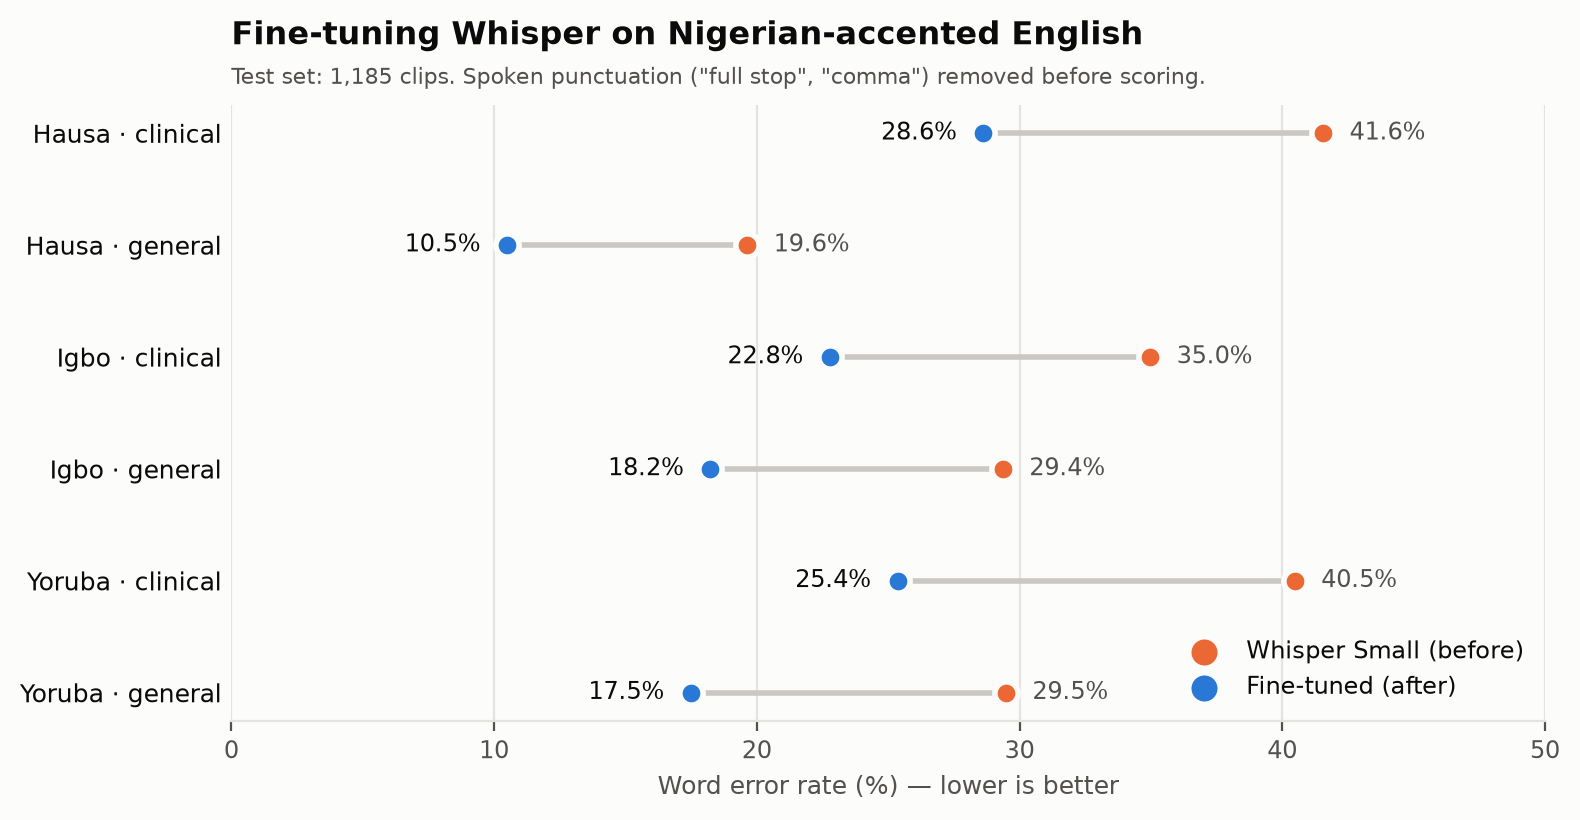

In [6]:
import matplotlib.pyplot as plt

s = pd.read_csv("../results/wer_summary.csv")
s = s[s["accent"] != "overall"]
w = s.pivot_table(index=["accent", "domain"], columns="model", values="adjusted_wer") * 100
w = w.reindex([(a, d) for a in ["hausa", "igbo", "yoruba"] for d in ["clinical", "general"]])

BASE, FT = "#eb6834", "#2a78d6"            # orange = before, blue = after
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=200)
fig.patch.set_facecolor("#fcfcfb"); ax.set_facecolor("#fcfcfb")
ys = list(range(len(w)))[::-1]
for y, ((acc, dom), r) in zip(ys, w.iterrows()):
    b, f = r["baseline"], r["fine-tuned"]
    ax.plot([f, b], [y, y], color="#c9c8c3", lw=2, zorder=1)
    ax.scatter(b, y, s=70, color=BASE, zorder=2, edgecolor="#fcfcfb", linewidth=2)
    ax.scatter(f, y, s=70, color=FT, zorder=3, edgecolor="#fcfcfb", linewidth=2)
    ax.text(b + 1, y, f"{b:.1f}%", va="center", ha="left", fontsize=8.5, color=MUTED)
    ax.text(f - 1, y, f"{f:.1f}%", va="center", ha="right", fontsize=8.5, color=INK)

ax.set_yticks(ys)
ax.set_yticklabels([f"{a.capitalize()} · {d}" for a, d in w.index], fontsize=9, color=INK)
ax.set_xlim(0, 50)
ax.set_xlabel("Word error rate (%) — lower is better", fontsize=9, color=MUTED)
ax.tick_params(axis="x", colors=MUTED, labelsize=8.5)
ax.tick_params(axis="y", length=0)
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.spines["bottom"].set_color(GRID)

ax.scatter([], [], s=70, color=BASE, label="Whisper Small (before)")
ax.scatter([], [], s=70, color=FT, label="Fine-tuned (after)")
ax.legend(loc="lower right", frameon=False, fontsize=8.5, labelcolor=INK)
ax.set_title("Fine-tuning Whisper on Nigerian-accented English", loc="left",
             fontsize=11.5, color=INK, fontweight="bold", pad=22)
ax.text(0, 1.035, "Test set: 1,185 clips. Spoken punctuation (\"full stop\", \"comma\") removed before scoring.",
        transform=ax.transAxes, fontsize=8, color=MUTED)
plt.tight_layout()
plt.savefig("../results/wer_before_after.png", facecolor="#fcfcfb")
plt.show()